Задача: предсказание стоимости продажи дома в долларах.

Краткое описание признаков:

* **LotArea** — размер участка в квадратных футах.
* **LotArea_M** — размер участка в квадратных метрах.
* **Street** — тип доступа к дороге.
* **BldgType** — тип жилья.
* **OverallQual** — общее качество материала и отделки.
* **OverallCond** — общая оценка состояния.
* **YearBuilt** — первоначальная дата постройки.
* **YearRemodAdd** — дата реконструкции.
* **RoofStyle** — тип крыши.
* **ExterQual** — качество материалов снаружи.
* **ExterCond** — текущее состояние материалов снаружи.
* **Foundation** — тип фундамента.
* **TotalBsmtSF** — общая площадь подвала в квадратных футах.
* **TotalBsmtSF_M** — общая площадь подвала в квадратных метрах.
* **Heating** — тип отопления.
* **HeatingQC** — качество и состояние отопления.
* **CentralAir** — кондиционирование.
* **GrLivArea** — жилая площадь в квадратных футах.
* **GrLivArea_M** — жилая площадь в квадратных метрах.
* **Bath** — количество ванных комнат.
* **KitchenQual** — качество кухни.
* **GarageArea** — площадь гаража в квадратных футах.
* **GarageArea_M** — площадь гаража в квадратных метрах.
* **DateSold** — месяц и год продажи.
* **SaleCondition** — условия сделки.
* **SalePrice** — стоимость продажи в долларах. Это целевая переменная, которую нам нужно предсказать.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from catboost import CatBoostRegressor
from catboost import cv, Pool

### Ознакомление с датасетом

In [2]:
data = pd.read_csv('data.csv')

In [3]:
df = data.copy()

In [4]:
df.head()

,LotArea,LotArea_M,Street,BldgType,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,ExterQual,...,CentralAir,GrLivArea,GrLivArea_M,Bath,KitchenQual,GarageArea,GarageArea_M,DateSold,SaleCondition,SalePrice
0,8450,785.03035,Pave,1Fam,7,5,2003,2003,Gable,Gd,...,Y,1710,158.864130,3,Gd,548,50.910844,2/2008,Normal,208500
1,9600,891.86880,Pave,1Fam,6,8,1976,1976,Gable,TA,...,Y,1262,117.243586,2,TA,460,42.735380,5/2007,Normal,181500
2,11250,1045.15875,Pave,1Fam,7,5,2001,2002,Gable,Gd,...,Y,1786,165.924758,3,Gd,608,56.485024,9/2008,Normal,223500
3,9550,887.22365,Pave,1Fam,7,5,1915,1970,Gable,TA,...,Y,1717,159.514451,1,Gd,642,59.643726,2/2006,Abnorml,140000
4,14260,1324.79678,Pave,1Fam,8,5,2000,2000,Gable,Gd,...,Y,2198,204.200794,3,Gd,836,77.666908,12/2008,Normal,250000


### Feature Engineering

In [5]:
# Выделяем месяц и год из даты
df['SaleMonth'] = df['DateSold'].apply(lambda x: int(x.split('/')[0]))
df['SaleYear'] = df['DateSold'].apply(lambda x: int(x.split('/')[1]))
df = df.drop('DateSold', axis=1)

In [6]:
# Возраст дома
df['HouseAge'] = df['SaleYear'] - df['YearBuilt']
df['RemodAge'] = df['SaleYear'] - df['YearRemodAdd']

In [7]:
# Удаляем дублирующие признаки (метры)
df = df.drop(columns=[
    'LotArea_M',
    'GrLivArea_M',
    'TotalBsmtSF_M',
    'GarageArea_M'
])

### Ознакомление с количеством пропущенных значений

In [8]:
print('Информация о выборке:\n')
df.info()

Информация о выборке:

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   LotArea        1460 non-null   int64
 1   Street         1460 non-null   str  
 2   BldgType       1460 non-null   str  
 3   OverallQual    1460 non-null   int64
 4   OverallCond    1460 non-null   int64
 5   YearBuilt      1460 non-null   int64
 6   YearRemodAdd   1460 non-null   int64
 7   RoofStyle      1460 non-null   str  
 8   ExterQual      1460 non-null   str  
 9   ExterCond      1460 non-null   str  
 10  Foundation     1460 non-null   str  
 11  TotalBsmtSF    1460 non-null   int64
 12  Heating        1460 non-null   str  
 13  HeatingQC      1460 non-null   str  
 14  CentralAir     1460 non-null   str  
 15  GrLivArea      1460 non-null   int64
 16  Bath           1460 non-null   int64
 17  KitchenQual    1460 non-null   str  
 18  GarageArea     1460 non-null   int64

In [9]:
# Делим данные на тренировочную и тестовую выборки
y = df['SalePrice']
X = df.drop('SalePrice', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

### Нахождение аномалий и выбросов

Напишем функцию, вычисляющую границы, в которые должны попадать нормальные значения. Нижняя граница рассчитывается как разница между нижним квартилем и интерквартильным размахом, помноженным на 1,5, а верхняя — как сумма интерквартильного размаха и верхнего квартиля, умноженного на 1,5.

In [10]:
def calculate_outliers(data):
    q25 = data.quantile(0.25)
    q75 = data.quantile(0.75)
    iqr = q75 - q25
    boundaries = (q25 - 1.5 * iqr, q75 + 1.5 * iqr)

    return boundaries

In [11]:
numeric_columns = df.select_dtypes(include=['int', 'float']).columns.tolist()
numeric_columns

['LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'TotalBsmtSF',
 'GrLivArea',
 'Bath',
 'GarageArea',
 'SalePrice',
 'SaleMonth',
 'SaleYear',
 'HouseAge',
 'RemodAge']

In [12]:
for each in numeric_columns:
    print(each)
    print(df[each].describe().apply(lambda x: f'{x:0.3f}'))

    boundaries = calculate_outliers(df[each])
    print('boundaries:', boundaries)
    
    print(' ')

LotArea
count      1460.000
mean      10516.828
std        9981.265
min        1300.000
25%        7553.500
50%        9478.500
75%       11601.500
max      215245.000
Name: LotArea, dtype: str
boundaries: (np.float64(1481.5), np.float64(17673.5))
 
OverallQual
count    1460.000
mean        6.099
std         1.383
min         1.000
25%         5.000
50%         6.000
75%         7.000
max        10.000
Name: OverallQual, dtype: str
boundaries: (np.float64(2.0), np.float64(10.0))
 
OverallCond
count    1460.000
mean        5.575
std         1.113
min         1.000
25%         5.000
50%         5.000
75%         6.000
max         9.000
Name: OverallCond, dtype: str
boundaries: (np.float64(3.5), np.float64(7.5))
 
YearBuilt
count    1460.000
mean     1971.268
std        30.203
min      1872.000
25%      1954.000
50%      1973.000
75%      2000.000
max      2010.000
Name: YearBuilt, dtype: str
boundaries: (np.float64(1885.0), np.float64(2069.0))
 
YearRemodAdd
count    1460.000
mean     19

In [14]:
# Удаляем логические противоречия для признака GrLivArea  (данные домов с высокой площадью и низкой ценой). 
train = X_train.copy()
train['SalePrice'] = y_train

train = train[~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000))]

X_train = train.drop('SalePrice', axis=1)
y_train = train['SalePrice']

In [15]:
def feature_engineering(df):
    df = df.copy()
    
    df['LotArea_log'] = np.log1p(df['LotArea'])
    df['TotalBsmtSF_log'] = np.log1p(df['TotalBsmtSF'])
    df['GrLivArea_log'] = np.log1p(df['GrLivArea'])
    
    df['TotalArea'] = df['GrLivArea'] + df['TotalBsmtSF']
    df['TotalArea_log'] = np.log1p(df['TotalArea'])

    # Взаимодействие признаков (Interactions)
    df['Qual_x_TotalArea'] = df['OverallQual'] * df['TotalArea']
    df['Qual_x_TotalArea_log'] = np.log1p(df['Qual_x_TotalArea'])
    
    df = df.drop(columns=[
        'LotArea', 'TotalBsmtSF', 'GrLivArea',
        'TotalArea', 'Qual_x_TotalArea',
        'TotalArea_log', 'OverallQual'
    ])
    
    return df

In [16]:
X_train = feature_engineering(X_train)
X_test = feature_engineering(X_test)

In [17]:
# Логарифм таргета
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

Были выявлены аномальные значения в признаках LotArea, TotalBsmtSF, GrLivArea, SalePrice с помощью метода межквартильного размаха. Вместо удаления или обрезки значений было применено логарифмическое преобразование признака, что позволило снизить влияние экстремальных значений и сохранить информацию. Использование модели CatBoost позволило снизить чувствительность к выбросам.

### Обучение, предсказание, feature importance

In [18]:
# Категориальные признаки
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()

C:\Users\user45\AppData\Local\Temp\ipykernel_5540\3731523922.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X_train.select_dtypes(include=['object']).columns.tolist()


In [19]:
# Модель CatBoost
model = CatBoostRegressor(
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)

In [20]:
# Обучение
model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50,
    use_best_model=True
)

0:	learn: 0.3812557	test: 0.3995808	best: 0.3995808 (0)	total: 197ms	remaining: 3m 17s
100:	learn: 0.1171201	test: 0.1374935	best: 0.1374935 (100)	total: 3.15s	remaining: 28.1s
200:	learn: 0.1000133	test: 0.1320318	best: 0.1319358 (195)	total: 6.34s	remaining: 25.2s
300:	learn: 0.0902825	test: 0.1316157	best: 0.1316157 (300)	total: 9.44s	remaining: 21.9s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.1313213086
bestIteration = 336

Shrink model to first 337 iterations.


In [21]:
# Предсказание
y_pred_log = model.predict(X_test)

# Преобразование из логарифма
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

In [22]:
# Расчет метрик до применения feature importance
rmse_before = np.sqrt(mean_squared_error(y_test_original, y_pred))
mae_before = mean_absolute_error(y_test_original, y_pred)
r2_before = r2_score(y_test_original, y_pred)

print("RMSE:", rmse_before)
print(f"MAE: {mae_before}")
print(f"R2: {r2_before}")

RMSE: 25163.0086500363
MAE: 15704.884607473725
R2: 0.9092621816195587


In [23]:
# Важность признаков (feature importance)
feature_importance = model.get_feature_importance()
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values(by='importance', ascending=False)

print(importance_df)

                 feature  importance
23  Qual_x_TotalArea_log   45.710028
20           LotArea_log    7.118503
14            GarageArea    6.224935
22         GrLivArea_log    5.464433
13           KitchenQual    5.027231
11            CentralAir    4.504723
18              HouseAge    4.325391
2            OverallCond    3.479648
4           YearRemodAdd    2.652577
12                  Bath    2.424836
21       TotalBsmtSF_log    2.388069
15         SaleCondition    2.276394
19              RemodAge    1.620682
3              YearBuilt    1.311303
1               BldgType    1.284810
16             SaleMonth    0.795931
8             Foundation    0.726128
17              SaleYear    0.646670
6              ExterQual    0.628081
7              ExterCond    0.538993
10             HeatingQC    0.446930
5              RoofStyle    0.200933
9                Heating    0.198956
0                 Street    0.003818


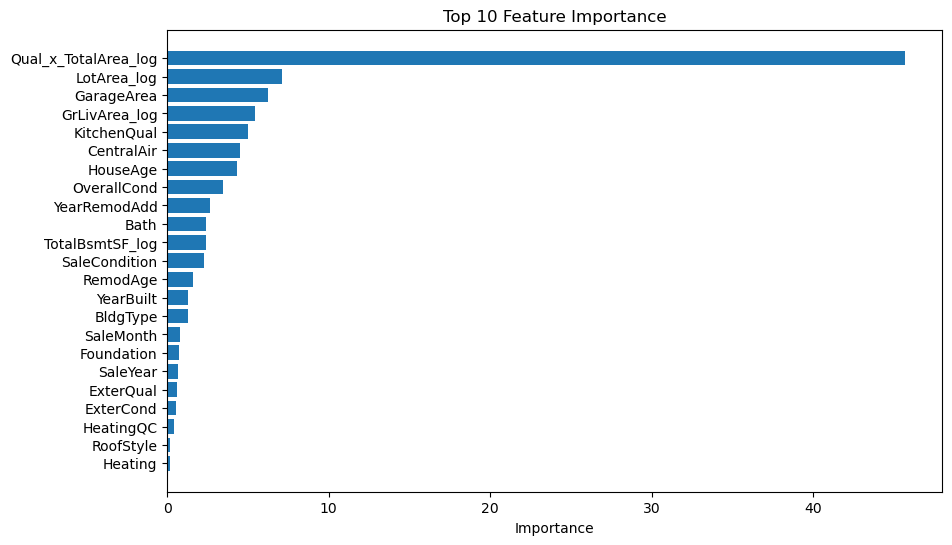

In [24]:
top_features = importance_df.head(23)

plt.figure(figsize=(10,6))
plt.barh(top_features['feature'][::-1], top_features['importance'][::-1])
plt.title('Top 10 Feature Importance')
plt.xlabel('Importance')
plt.show()

Наибольшее влияние на цену дома оказывают: Qual_x_TotalArea_log, размер участка в квадратных футах (LotArea_log), площадь гаража в квадратных футах (GarageArea), жилая площадь (GrLivArea_log). 

In [25]:
# Отбираем признаки, у которых важность >= 0.5
final_features = importance_df[importance_df['importance'] >= 0.5]['feature'].tolist()

# Формируем новые выборки
X_train_sel = X_train[final_features]
X_test_sel = X_test[final_features]

In [26]:
cat_features_sel = [f for f in cat_features if f in final_features]

In [27]:
# Обучение после feature importance
model.fit(
    X_train_sel,
    y_train,
    cat_features=cat_features_sel,
    eval_set=(X_test_sel, y_test),
    early_stopping_rounds=50
)

0:	learn: 0.3813394	test: 0.3997971	best: 0.3997971 (0)	total: 34.5ms	remaining: 34.5s
100:	learn: 0.1176748	test: 0.1380502	best: 0.1380502 (100)	total: 2.88s	remaining: 25.6s
200:	learn: 0.1001871	test: 0.1315177	best: 0.1315177 (200)	total: 5.56s	remaining: 22.1s
300:	learn: 0.0885592	test: 0.1307283	best: 0.1305547 (274)	total: 8.24s	remaining: 19.1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.1305546618
bestIteration = 274

Shrink model to first 275 iterations.


In [28]:
# Предсказание после feature importance
y_pred_log = model.predict(X_test_sel)

# Преобразование из логарифма
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

In [29]:
# Метрики после feature importance
rmse_after = np.sqrt(mean_squared_error(y_test_original, y_pred))
mae_after = mean_absolute_error(y_test_original, y_pred)
r2_after = r2_score(y_test_original, y_pred)

print("RMSE:", rmse_after)
print(f"MAE: {mae_after}")
print(f"R2: {r2_after}")

RMSE: 24781.44161607394
MAE: 15600.850919191407
R2: 0.9119931789956035


In [30]:
metrics_df = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'R2'],
    'Before': [rmse_before, mae_before, r2_before],
    'After': [rmse_after, mae_after, r2_after]
})

print(metrics_df)

  Metric        Before         After
0   RMSE  25163.008650  24781.441616
1    MAE  15704.884607  15600.850919
2     R2      0.909262      0.911993


После применения отбора признаков на основе важности, полученной из модели CatBoost, наблюдается незначительное увеличение качества модели.

### Кросс-валидация

Для оценки стабильности модели и исключения влияния случайного разбиения данных используем 5-fold кросс-валидацию. Это позволит подтвердить, что модель стабильна и не переобучена.

In [31]:
# Подготовка данных для кросс-валидации
cv_pool = Pool(
    data=X_train_sel,
    label=y_train,
    cat_features=cat_features_sel
)

# Параметры модели 
params = {
    "iterations": 1000,
    "depth": 6,
    "learning_rate": 0.05,
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "random_seed": 42,
    "verbose": False
}

cv_results = cv(
    pool=cv_pool,
    params=params,
    fold_count=5,
    shuffle=True,
    partition_random_seed=42
)

final_rmse = cv_results['test-RMSE-mean'].iloc[-1]

print(f"CV RMSE (log scale): {final_rmse:.4f}")

Training on fold [0/5]

bestTest = 0.2754925543
bestIteration = 999

Training on fold [1/5]

bestTest = 0.3001688333
bestIteration = 992

Training on fold [2/5]

bestTest = 0.2334552568
bestIteration = 997

Training on fold [3/5]

bestTest = 0.3376736138
bestIteration = 957

Training on fold [4/5]

bestTest = 0.2437225473
bestIteration = 997

CV RMSE (log scale): 0.2781


In [34]:
rmse_test_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
print(rmse_test_log)

0.13055466428699858


In [35]:
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
print(baseline_rmse)

0.41219266173385793


Базовая модель (предсказание среднего значения) показала RMSE = 0.412, в то время как модель CatBoost снизила ошибку до 0.278 по результатам кросс-валидации, что свидетельствует о способности модели эффективно улавливать зависимости в данных.

При этом значение RMSE на тестовой выборке составило 0.131, что значительно ниже результата кросс-валидации. Это может указывать на то, что тестовая выборка оказалась более простой или менее разнообразной, чем обучающие подвыборки.

В целом, ориентироваться следует на результат кросс-валидации (RMSE ≈ 0.278), так как он является более устойчивой и надежной оценкой качества модели.

### Анализ остатков и распределения ошибок модели

Проверим, какой вклад в эту ошибку вносят самые дорогие дома через график остатков (Residuals Plot)

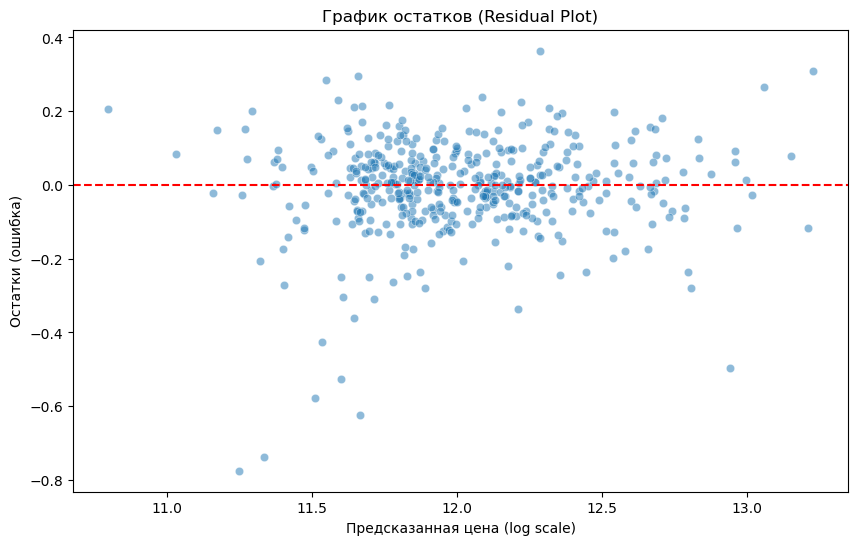

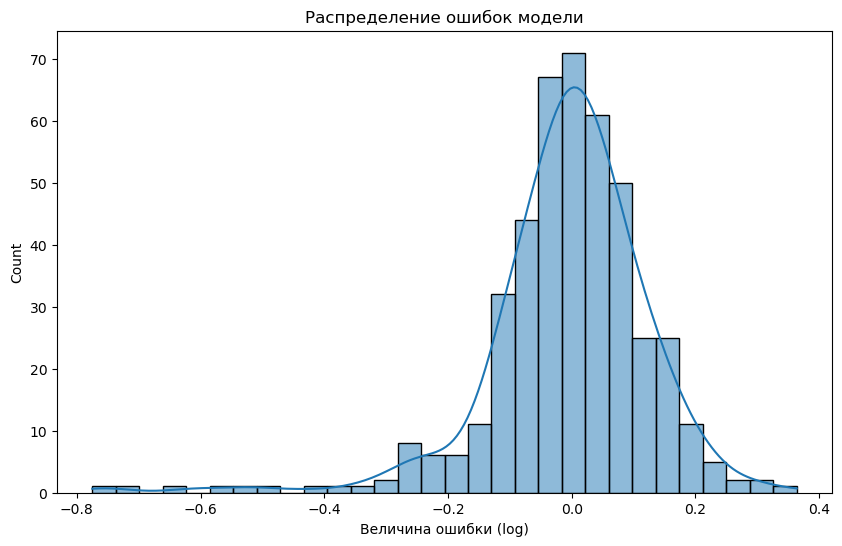

In [37]:
# График остатков (Residuals Plot)
# Получаем предсказания на тестовой выборке
y_pred_log = model.predict(X_test[final_features])
# Считаем остатки (разница между реальностью и предсказанием в лог-шкале)
residuals = y_test - y_pred_log

# Строим график
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_log, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('График остатков (Residual Plot)')
plt.xlabel('Предсказанная цена (log scale)')
plt.ylabel('Остатки (ошибка)')
plt.show()

# Распределение ошибок
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30)
plt.title('Распределение ошибок модели')
plt.xlabel('Величина ошибки (log)')
plt.show()

В результате анализа графика Residual Plot мы видим, что:
1. Большинство точек распределены вокруг нуля (что означает, что модель не имеет сильного глобального смещения (bias) и нет систематической ошибки (постоянного завышения/занижения). 
2. Присутствуют выбросы:
- есть точки сильно ниже 0 (модель сильно переоценила цену),
- есть точки выше 0 (модель недооценила цену).
3. Систематическая ошибка в низком сегменте: мы наблюдаем много сильных отрицательных остатков слева (модель часто переоценивает дешёвые дома).
  4. Наблюдается гетероскедастичность: разброс остатков меняется в зависимости от уровня предсказания.

В результате анализа графика распределения ошибок мы видим:
1. Наблюдается почти нормальное распределение (форма колокола, центр около 0).
Что говорит о том, что модель в среднем не ошибается системно и нет сильного bias (постоянного завышения/занижения).
2. Присутствует небольшая асимметрия влево: левый хвост длиннее (до ~ -0.7), правый хвост короче (до ~ 0.3–0.35).

В результате применения модели CatBoost удалось достичь высокого качества прогнозирования. RMSE: 23612.36, MAE: 15398.92,
R2: 0.904097. Это свидетельствует о том, что модель успешно улавливает зависимости между признаками и целевой переменной. Несмотря на высокий результат, модель допускает ошибки на объектах с экстремальными значениями. Для дальнейшего улучшения возможно: добавление в выборку большего количества объектов с экстремальными значениями, сегментации рынка (например, дешёвые/средние/дорогие дома), применение ансамблирования: усреднение предсказания CatBoost, XGBoost и Lasso-регрессии. Для оптимизации гиперпараметров возможно использование библиотеки Optuna. 